Puedes comprar versiones impresas y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');
download('https://github.com/ramalho/jupyturtle/releases/download/2024-03/jupyturtle.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py
Downloaded jupyturtle.py


# Condicionales y recursión

El tema principal de este capítulo es la sentencia `if`, que ejecuta código distinto según el estado del programa.
Y con la sentencia `if` podremos explorar una de las ideas más potentes de la informática: la **recursión**.

Pero empezaremos con tres características nuevas: el operador módulo, las expresiones booleanas y los operadores lógicos.

## División entera y módulo

Recuerda que el operador de división entera, `//`, divide dos números y redondea
hacia abajo hasta un entero.
Por ejemplo, supón que la duración de una película es de 105 minutos.
Puede que quieras saber cuánto es eso en horas.
La división convencional devuelve un número de punto flotante:

In [ ]:
minutes = 105
minutes / 60

Pero normalmente no escribimos las horas con decimales.
La división entera devuelve el número entero de horas, redondeando hacia abajo:

In [ ]:
minutes = 105
hours = minutes // 60
hours

Para obtener el resto, podrías restar una hora expresada en minutos:

In [ ]:
remainder = minutes - hours * 60
remainder

O podrías usar el **operador módulo**, `%`, que divide dos números y devuelve el resto.

In [ ]:
remainder = minutes % 60
remainder

El operador módulo es más útil de lo que podría parecer.
Por ejemplo, puede comprobar si un número es divisible por otro: si `x % y` es cero, entonces `x` es divisible por `y`.

También puede extraer el dígito o los dígitos más a la derecha de un número.
Por ejemplo, `x % 10` produce el dígito más a la derecha de `x` (en base 10).
De forma similar, `x % 100` produce los dos últimos dígitos.

In [ ]:
x = 123
x % 10

In [ ]:
x % 100

Por último, el operador módulo puede hacer «aritmética de reloj».
Por ejemplo, si un evento empieza a las 11 AM y dura tres horas, podemos usar el operador módulo para averiguar a qué hora termina.

In [ ]:
start = 11
duration = 3
end = (start + duration) % 12
end

El evento terminaría a las 2 PM.

## Expresiones booleanas

Una **expresión booleana** es una expresión que es verdadera o falsa.
Por ejemplo, las siguientes expresiones usan el operador de igualdad, `==`, que compara dos valores y produce `True` si son iguales y `False` en caso contrario:

In [ ]:
5 == 5

In [ ]:
5 == 7

Un error común es usar un solo signo igual (`=`) en lugar de un doble signo igual (`==`).
Recuerda que `=` asigna un valor a una variable y `==` compara dos valores.

In [ ]:
x = 5
y = 7

In [ ]:
x == y

`True` y `False` son valores especiales que pertenecen al tipo `bool`;
no son cadenas:

In [ ]:
type(True)

In [ ]:
type(False)

El operador `==` es uno de los **operadores relacionales**; los otros son:

In [ ]:
x != y               # x is not equal to y

In [ ]:
x > y                # x is greater than y

In [ ]:
x < y               # x is less than to y

In [ ]:
x >= y               # x is greater than or equal to y

In [ ]:
x <= y               # x is less than or equal to y

## Operadores lógicos

Para combinar valores booleanos en expresiones, podemos usar **operadores lógicos**.
Los más comunes son `and`, ` or` y `not`.
El significado de estos operadores es parecido a su significado en inglés.
Por ejemplo, el valor de la siguiente expresión es `True` solo si `x` es mayor que `0` *y* menor que `10`.

In [ ]:
x > 0 and x < 10

La siguiente expresión es `True` si *una o ambas* condiciones son verdaderas, es decir, si el número es divisible por 2 *o* por 3:

In [ ]:
x % 2 == 0 or x % 3 == 0

Por último, el operador `not` niega una expresión booleana, de modo que la siguiente expresión es `True` si `x > y` es `False`.

In [ ]:
not x > y

En sentido estricto, los operandos de un operador lógico deberían ser expresiones booleanas, pero Python no es muy estricto.
Cualquier número distinto de cero se interpreta como `True`:

In [ ]:
42 and True

Esta flexibilidad puede ser útil, pero tiene algunas sutilezas que pueden resultar confusas.
Quizá prefieras evitarla.

## Sentencias `if`

Para escribir programas útiles, casi siempre necesitamos la capacidad de
comprobar condiciones y cambiar el comportamiento del programa en consecuencia.
Las **sentencias condicionales** nos dan esta capacidad. La forma más sencilla es
la sentencia `if`:

In [ ]:
if x > 0:
    print('x is positive')

`if` es una palabra clave de Python.
Las sentencias `if` tienen la misma estructura que las definiciones de función: una
cabecera seguida de una sentencia indentada o de una secuencia de sentencias llamada **bloque**.

La expresión booleana que va después de `if` se llama **condición**.
Si es verdadera, se ejecutan las sentencias del bloque indentado. Si no, no se ejecutan.

No hay límite para el número de sentencias que pueden aparecer en el bloque, pero tiene que haber al menos una.
A veces resulta útil tener un bloque que no hace nada, normalmente como marcador de posición para código que todavía no has escrito.
En ese caso, puedes usar la sentencia `pass`, que no hace nada.

In [ ]:
if x < 0:
    pass          # TODO: need to handle negative values!

La palabra `TODO` en un comentario es un recordatorio convencional de que hay algo que tienes que hacer más adelante.

## La cláusula `else`

Una sentencia `if` puede tener una segunda parte, llamada cláusula `else`.
La sintaxis tiene este aspecto:

In [ ]:
if x % 2 == 0:
    print('x is even')
else:
    print('x is odd')

Si la condición es verdadera, se ejecuta la primera sentencia indentada; si no, se ejecuta la segunda sentencia indentada.

En este ejemplo, si `x` es par, el resto al dividir `x` entre `2` es `0`, así que la condición es verdadera y el programa muestra `x is even`.
Si `x` es impar, el resto es `1`, así que la condición
es falsa, y el programa muestra `x is odd`.

Como la condición debe ser verdadera o falsa, se ejecutará exactamente una de las alternativas.
Las alternativas se llaman **ramas**.

## Condicionales encadenados

A veces hay más de dos posibilidades y necesitamos más de dos ramas.
Una forma de expresar un cálculo así es un **condicional encadenado**, que incluye una cláusula `elif`.

In [ ]:
if x < y:
    print('x is less than y')
elif x > y:
    print('x is greater than y')
else:
    print('x and y are equal')

`elif` es una abreviatura de «else if».
No hay límite en el número de cláusulas `elif`.
Si hay una cláusula `else`, tiene que ir al final, pero no tiene por qué haber
una.

Cada condición se comprueba en orden.
Si la primera es falsa, se comprueba la siguiente, y así sucesivamente.
Si una de ellas es verdadera, se ejecuta la rama correspondiente y termina la sentencia `if`.
Aunque más de una condición sea verdadera, solo se ejecuta la primera rama verdadera.

## Condicionales anidados

Un condicional también puede estar anidado dentro de otro.
Podríamos haber escrito el ejemplo de la sección anterior así:

In [ ]:
if x == y:
    print('x and y are equal')
else:
    if x < y:
        print('x is less than y')
    else:
        print('x is greater than y')

La sentencia `if` exterior contiene dos ramas.
La primera rama contiene una sentencia sencilla. La segunda rama contiene otra sentencia `if`, que tiene dos ramas propias.
Esas dos ramas son ambas sentencias sencillas, aunque también podrían haber sido sentencias condicionales.

Aunque la indentación de las sentencias hace visible la estructura, los **condicionales anidados** pueden ser difíciles de leer.
Te sugiero que los evites cuando puedas.

Los operadores lógicos suelen proporcionar una forma de simplificar sentencias condicionales anidadas.
Aquí tienes un ejemplo con un condicional anidado.

In [ ]:
if 0 < x:
    if x < 10:
        print('x is a positive single-digit number.')

La sentencia `print` se ejecuta solo si superamos ambos condicionales, así que conseguimos el mismo efecto con el operador `and`.

In [ ]:
if 0 < x and x < 10:
    print('x is a positive single-digit number.')

Para este tipo de condición, Python ofrece una opción más concisa:

In [ ]:
if 0 < x < 10:
    print('x is a positive single-digit number.')

## Recursión

Es legal que una función se llame a sí misma.
Puede que no sea obvio por qué eso es algo bueno, pero resulta ser una de las cosas más mágicas que puede hacer un programa.
Aquí tienes un ejemplo.

In [ ]:
def countdown(n):
    if n <= 0:
        print('Blastoff!')
    else:
        print(n)
        countdown(n-1)

Si `n` es 0 o negativo, `countdown` muestra la palabra «Blastoff!». En caso contrario,
muestra `n` y luego se llama a sí misma, pasando `n-1` como argumento.

Esto es lo que ocurre cuando llamamos a esta función con el argumento `3`.

In [ ]:
countdown(3)

La ejecución de `countdown` empieza con `n=3`, y como `n` es mayor
que `0`, muestra `3` y luego se llama a sí misma\...

> La ejecución de `countdown` empieza con `n=2`, y como `n` es
> mayor que `0`, muestra `2` y luego se llama a sí misma\...
>
> > La ejecución de `countdown` empieza con `n=1`, y como `n` es
> > mayor que `0`, muestra `1` y luego se llama a sí misma\...
> >
> > > La ejecución de `countdown` empieza con `n=0`, y como `n` no es
> > > mayor que `0`, muestra «Blastoff!» y retorna.
> >
> > La `countdown` que recibió `n=1` retorna.
>
> La `countdown` que recibió `n=2` retorna.

La `countdown` que recibió `n=3` retorna.

Una función que se llama a sí misma es **recursiva**.
Como otro ejemplo, podemos escribir una función que imprime una cadena `n` veces.

In [ ]:
def print_n_times(string, n):
    if n > 0:
        print(string)
        print_n_times(string, n-1)

Si `n` es positivo, `print_n_times` muestra el valor de `string` y luego se llama a sí misma, pasando `string` y `n-1` como argumentos.

Si `n` es `0` o negativo, la condición es falsa y `print_n_times` no hace nada.

Así es como funciona.

In [ ]:
print_n_times('Spam ', 4)

Para ejemplos sencillos como este, probablemente sea más fácil usar un bucle `for`.
Pero más adelante veremos ejemplos que son difíciles de escribir con un bucle `for`
y fáciles de escribir con recursión, así que conviene empezar pronto.

## Diagramas de stack para funciones recursivas

Aquí tienes un diagrama de stack que muestra los marcos creados cuando llamamos a `countdown` con `n = 3`.

In [ ]:
from diagram import make_frame, Stack

frames = []
for n in [3,2,1,0]:
    d = dict(n=n)
    frame = make_frame(d, name='countdown', dy=-0.3, loc='left')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

In [ ]:
from diagram import diagram, adjust


width, height, x, y = [1.74, 2.04, 1.05, 1.77]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

Los cuatro marcos de `countdown` tienen valores distintos para el parámetro `n`.
La parte inferior del stack, donde `n=0`, se llama **caso base**.
No hace una llamada recursiva, así que no hay más marcos.

In [ ]:
from diagram import make_frame, Stack
from diagram import diagram, adjust

frames = []
for n in [2,1,0]:
    d = dict(string='Hello', n=n)
    frame = make_frame(d, name='print_n_times', dx=1.3, loc='left')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

width, height, x, y = [3.53, 1.54, 1.54, 1.27]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

## Recursión infinita

Si una recursión nunca alcanza un caso base, sigue haciendo llamadas
recursivas para siempre, y el programa nunca termina. Esto se conoce como
**recursión infinita**, y por lo general no es una buena idea.
Aquí tienes una función mínima con una recursión infinita.

In [ ]:
def recurse():
    recurse()

Cada vez que se llama a `recurse`, se llama a sí misma, lo que crea otro marco.
En Python, hay un límite para el número de marcos que pueden estar en el stack al mismo tiempo.
Si un programa supera el límite, provoca un error en tiempo de ejecución.

In [ ]:
%xmode Context

In [ ]:
%%expect RecursionError

recurse()

El traceback indica que había casi 3000 marcos en el stack cuando ocurrió el error.

Si te encuentras por accidente con una recursión infinita, revisa tu función para confirmar que hay un caso base que no hace una llamada recursiva. Y si hay un caso base, comprueba si tienes garantizado llegar a él.

## Entrada por teclado

Los programas que hemos escrito hasta ahora no aceptan entrada del usuario. Simplemente
hacen lo mismo cada vez.

Python proporciona una función integrada llamada `input` que detiene el
programa y espera a que el usuario escriba algo. Cuando el usuario pulsa
*Return* o *Enter*, el programa continúa y `input` devuelve lo que el usuario
ha escrito como una cadena.

In [ ]:
# Solution goes here

In [ ]:
text = input()

Antes de obtener entrada del usuario, puede que quieras mostrar un prompt
que le indique qué debe escribir. `input` puede recibir un prompt como argumento:

In [ ]:
# Solution goes here

In [ ]:
name = input('What...is your name?\n')
name

La secuencia `
` al final del prompt representa una **nueva línea**, que es un carácter especial que provoca un salto de línea; así, la entrada del usuario aparece debajo del prompt.

Si esperas que el usuario escriba un entero, puedes usar la función `int` para convertir el valor de retorno a `int`.

In [ ]:
# Solution goes here

In [ ]:
prompt = 'What...is the airspeed velocity of an unladen swallow?\n'
speed = input(prompt)
speed

Pero si escribe algo que no es un entero, obtendrás un error en tiempo de ejecución.

In [ ]:
%xmode Minimal

In [ ]:
%%expect ValueError

int(speed)

Más adelante veremos cómo manejar este tipo de error.

## Debugging

Cuando ocurre un error de sintaxis o en tiempo de ejecución, el mensaje de error contiene mucha
información, pero puede resultar abrumador. Las partes más útiles suelen ser:

-   Qué tipo de error fue, y

-   Dónde ocurrió.

Los errores de sintaxis suelen ser fáciles de encontrar, pero hay algunas trampas.
Los errores relacionados con espacios y tabulaciones pueden ser complicados porque son invisibles
y estamos acostumbrados a ignorarlos.

In [ ]:
%%expect IndentationError
x = 5
 y = 6

En este ejemplo, el problema es que la segunda línea está indentada con un espacio.
Pero el mensaje de error señala a `y`, lo que resulta engañoso.
Los mensajes de error indican dónde se descubrió el problema, pero el error real podría estar antes en el código.

Lo mismo ocurre con los errores en tiempo de ejecución.
Por ejemplo, supón que intentas convertir una razón a decibelios, así:

In [ ]:
%xmode Context

In [ ]:
%%expect ValueError
import math
numerator = 9
denominator = 10
ratio = numerator // denominator
decibels = 10 * math.log10(ratio)

El mensaje de error indica la línea 5, pero no hay nada malo en esa línea.
El problema está en la línea 4, que usa división entera en lugar de división de punto flotante; como resultado, el valor de `ratio` es `0`.
Cuando llamamos a `math.log10`, obtenemos un `ValueError` con el mensaje `math domain error`, porque `0` no está en el «dominio» de argumentos válidos para `math.log10`, ya que el logaritmo de `0` no está definido.

En general, deberías tomarte el tiempo de leer cuidadosamente los mensajes de error, pero no asumas que todo lo que dicen es correcto.

## Glosario

**recursión:**
El proceso de llamar a la función que se está ejecutando en ese momento.

**operador módulo:**
Un operador, `%`, que funciona con enteros y devuelve el resto cuando un número se divide entre otro.

**expresión booleana:**
Una expresión cuyo valor es `True` o `False`.

**operador relacional:**
Uno de los operadores que compara sus operandos: `==`, `!=`, `>`, `<`, `>=` y `<=`.

**operador lógico:**
Uno de los operadores que combina expresiones booleanas, incluidos `and`, `or` y `not`.

**sentencia condicional:**
Una sentencia que controla el flujo de ejecución dependiendo de alguna condición.

**condición:**
La expresión booleana en una sentencia condicional que determina qué rama se ejecuta.

**bloque:**
Una o más sentencias indentadas para indicar que forman parte de otra sentencia.

**rama:**
Una de las secuencias alternativas de sentencias en una sentencia condicional.

**condicional encadenado:**
Una sentencia condicional con una serie de ramas alternativas.

**condicional anidado:**
Una sentencia condicional que aparece en una de las ramas de otra sentencia condicional.

**recursiva:**
Una función que se llama a sí misma es recursiva.

**caso base:**
Una rama condicional en una función recursiva que no hace una llamada recursiva.

**recursión infinita:**
Una recursión que no tiene caso base o que nunca lo alcanza.
Con el tiempo, una recursión infinita provoca un error en tiempo de ejecución.

**nueva línea:**
Un carácter que crea un salto de línea entre dos partes de una cadena.

## Ejercicios

In [ ]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

### Pregunta a un asistente virtual

* Pregunta a un asistente virtual: «¿Cuáles son algunos usos del operador módulo?»

* Python proporciona operadores para calcular las operaciones lógicas `and`, `or` y `not`, pero no tiene un operador que calcule la operación `or` exclusiva, que normalmente se escribe `xor`. Pregunta a un asistente: «¿Qué es la operación lógica xor y cómo la calculo en Python?»

En este capítulo, vimos dos formas de escribir una sentencia `if` con tres ramas: usando un condicional encadenado o un condicional anidado.
Puedes usar un asistente virtual para convertir de una forma a la otra.
Por ejemplo, pregunta a un asistente virtual: «Convierte esta sentencia en un condicional encadenado».

In [5]:
x = 5
y = 7

In [9]:
if x == y:
    print('x and y are equal')
else:
    if x < y:
        print('x is less than y')
    else:
        print('x is greater than y')

x is less than y


In [8]:
if x == y:
    print('x and y are equal')
elif x < y:
    print('x is less than y')
else:
    print('x is greater than y')

x is less than y


Pregunta a un asistente virtual: «Reescribe esta sentencia con un único condicional».

In [6]:
if 0 < x:
    if x < 10:
        print('x is a positive single-digit number.')

x is a positive single-digit number.


In [7]:
if 0 < x < 10:
    print('x is a positive single-digit number.')

x is a positive single-digit number.


Comprueba si un asistente virtual puede simplificar esta complejidad innecesaria.

In [11]:
if not x <= 0 and not x >= 10:
    print('x is a positive single-digit number.')

x is a positive single-digit number.


In [12]:
if x > 0 and x < 10:
   print('x is a positive single-digit number.')

x is a positive single-digit number.


Aquí tienes un intento de función recursiva que cuenta hacia atrás de dos en dos.

In [13]:
def countdown_by_two(n):
    if n == 0:
        print('Blastoff!')
    else:
        print(n)
        countdown_by_two(n-2)

Parece funcionar.

In [16]:
countdown_by_two(6)

6
4
2
Blastoff!


Pero tiene un error. Pregunta a un asistente virtual qué está mal y cómo arreglarlo.
Pega aquí la solución que te proporcione y pruébala.

In [17]:
def countdown_by_two(n):
    if n <= 0:
        print('Blastoff!')
    else:
        print(n)
        countdown_by_two(n-2)

In [18]:
countdown_by_two(5)

5
3
1
Blastoff!


### Ejercicio

El módulo `time` proporciona una función, también llamada `time`, que devuelve
el número de segundos transcurridos desde la «época Unix», que es el 1 de enero de 1970, 00:00:00 UTC (tiempo universal coordinado).

In [24]:
from time import time

now = time()
now

1780425354.7626805

Usa la división entera y el operador módulo para calcular el número de días transcurridos desde el 1 de enero de 1970 y la hora actual del día en horas, minutos y segundos.

Puedes leer más sobre el módulo `time` en <https://docs.python.org/3/library/time.html>.

In [32]:
# Solution goes here
segundos_por_dia = 24 * 60 * 60
dias = now // segundos_por_dia

print(dias)

20606.0


In [39]:
# Solution goes here
segundos_restantes = int(now % segundos_por_dia)

hora_actual = segundos_restantes // 3600
segundos_restantes = segundos_restantes % 3600

minutos = segundos_restantes // 60
segundos = segundos_restantes % 60

print("Hora:", hora_actual)
print("Minutos:", minutos)
print("Segundos:", segundos)

Hora: 19
Minutos: 2
Segundos: 45


In [40]:
# Solution goes here
from time import time

now = time()

segundos_por_dia = 24 * 60 * 60

dias = int(now // segundos_por_dia)

segundos_restantes = int(now % segundos_por_dia)

horas = segundos_restantes // 3600
segundos_restantes = segundos_restantes % 3600

minutos = segundos_restantes // 60
segundos = segundos_restantes % 60

print("Días:", dias)
print("Hora:", horas)
print("Minutos:", minutos)
print("Segundos:", segundos)

Días: 20606
Hora: 19
Minutos: 4
Segundos: 20


In [ ]:
# Solution goes here

### Ejercicio

Si te dan tres palos, puede que puedas colocarlos formando un triángulo, o puede que no. Por ejemplo, si uno de los palos mide 12 pulgadas
y los otros dos miden una pulgada, no podrás hacer que los
palos cortos se encuentren en el centro. Para tres longitudes cualesquiera, hay una
prueba para ver si es posible formar un triángulo:

> Si cualquiera de las tres longitudes es mayor que la suma de las otras dos,
> entonces no puedes formar un triángulo. En caso contrario, sí puedes. (Si la suma de
> dos longitudes es igual a la tercera, forman lo que se llama un triángulo
> «degenerado».)

Escribe una función llamada `is_triangle` que reciba tres enteros como
argumentos, y que imprima «Yes» o «No», dependiendo de
si se puede o no formar un triángulo con palos de las longitudes dadas.
Pista: usa un condicional encadenado.



In [41]:
# Solution goes here
def is_triangle (a, b, c):
    if a > b + c or b > c + a or c > b + a :
       print ('No puedes formar un triángulo')
    else:
       print ('Sí puedes formar un triángulo')

Prueba tu función con los siguientes casos.

In [42]:
is_triangle(4, 5, 6)   # should be Yes

Sí puedes formar un triángulo


In [43]:
is_triangle(1, 2, 3)   # should be Yes

Sí puedes formar un triángulo


In [44]:
is_triangle(6, 2, 3)   # should be No

No puedes formar un triángulo


In [45]:
is_triangle(1, 1, 12)   # should be No

No puedes formar un triángulo


### Ejercicio

¿Cuál es la salida del siguiente programa? Dibuja un diagrama de stack que
muestre el estado del programa cuando imprime el resultado.

In [ ]:
def recurse(n, s):
    if n == 0:
        print(s)
    else:
        recurse(n-1, n+s)

recurse(3, 0)

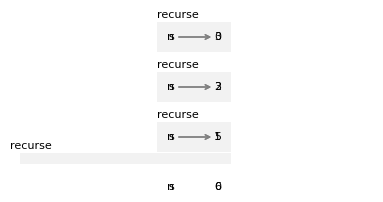

In [53]:
# Solution goes here
from diagram import make_frame, Stack, diagram
lista = [
    (3, 0),
    (2, 3),
    (1, 5),
    (0, 6)
]
frames = []
for n, s in lista:
    d = dict(n=n, s=s)
    frame = make_frame(d, name='recurse')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

width, height, x, y = [3.53, 1.54, 1.54, 1.27]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)


In [ ]:
# Solution goes here

### Ejercicio

Los siguientes ejercicios usan el módulo `jupyturtle`, descrito en el Capítulo 4.

Lee la siguiente función y mira si puedes averiguar qué hace.
Luego ejecútala y comprueba si acertaste.
Ajusta los valores de `length`, `angle` y `factor`, y observa qué efecto tienen en el resultado.
Si no tienes claro cómo funciona, prueba a preguntar a un asistente virtual.

In [59]:
from jupyturtle import forward, left, right, back

def draw(length):
    angle = 50
    factor = 0.6

    if length > 5:
        forward(length)
        left(angle)
        draw(factor * length)
        right(2 * angle)
        draw(factor * length)
        left(angle)
        back(length)



In [62]:
# Solution goes here
draw(20)

### Ejercicio

Pregunta a un asistente virtual: «¿Qué es la curva de Koch?»

Para dibujar una curva de Koch con longitud `x`, todo lo que
tienes que hacer es

1.  Dibujar una curva de Koch con longitud `x/3`.

2.  Girar a la izquierda 60 grados.

3.  Dibujar una curva de Koch con longitud `x/3`.

4.  Girar a la derecha 120 grados.

5.  Dibujar una curva de Koch con longitud `x/3`.

6.  Girar a la izquierda 60 grados.

7.  Dibujar una curva de Koch con longitud `x/3`.

La excepción es si `x` es menor que `5`; en ese caso, puedes dibujar simplemente una línea recta con longitud `x`.

Escribe una función llamada `koch` que reciba `x` como argumento y dibuje una curva de Koch con la longitud dada.


In [65]:
from jupyturtle import forward, left, right, make_turtle
# Solution goes here
def koch (x):
    if x >= 5:
       koch(x/3)
       left (60)
       koch(x/3)
       right (120)
       koch(x/3)
       left (60)
       koch(x/3)
    else:
       forward(x)



El resultado debería verse así:

In [68]:
make_turtle(delay=0)
koch(300)

Cuando tengas `koch` funcionando, puedes usar este bucle para dibujar tres curvas de Koch con forma de copo de nieve.

In [70]:
make_turtle(delay=0, height=300)
for i in range(3):
    koch(120)
    right(120)

### Ejercicio

Los asistentes virtuales conocen las funciones del módulo `jupyturtle`, pero hay muchas versiones de estas funciones, con nombres distintos, así que un asistente virtual podría no saber de cuál estás hablando.

Para resolver este problema, puedes proporcionar información adicional antes de hacer una pregunta.
Por ejemplo, podrías empezar un prompt con «Aquí tienes un programa que usa el módulo `jupyturtle`», y luego pegar uno de los ejemplos de este capítulo.
Después de eso, el asistente virtual debería poder generar código que use este módulo.

Como ejemplo, pide a un asistente virtual un programa que dibuje un triángulo de Sierpiński.
El código que obtengas debería ser un buen punto de partida, pero quizá tengas que hacer algo de debugging.
Si el primer intento no funciona, puedes contarle al asistente virtual qué ocurrió y pedir ayuda, o puedes depurarlo por tu cuenta.

In [76]:
# Solution goes here
from jupyturtle import forward, left, right, back

def sierpinski(length):
    if length < 10:
        for _ in range(3):
            forward(length)
            left(120)
    else:
        sierpinski(length / 2)

        forward(length / 2)
        sierpinski(length / 2)
        back(length / 2)

        left(60)
        forward(length / 2)
        right(60)

        sierpinski(length / 2)

        left(60)
        back(length / 2)
        right(60)

Este es un posible aspecto del resultado, aunque la versión que obtengas podría ser diferente.

In [77]:
make_turtle(delay=0, height=200)

sierpinski(100)

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Licencia del código: [MIT License](https://mit-license.org/)

Licencia del texto: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)